In [23]:
!pip install scikit-learn
!pip install fastai
!pip3 install torch torchvision --index-url https://download.pytorch.org/whl/cu132

Looking in indexes: https://download.pytorch.org/whl/cu132


In [2]:
import numpy as np
import pandas as pd
from fastai.vision.all import *

Reading the data

In [4]:
df = pd.read_csv('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/HAM10000_metadata.csv')
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Inspecting the datas

In [5]:
df.isna().sum()

lesion_id        0
image_id         0
dx               0
dx_type          0
age             57
sex              0
localization     0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

As we can observe that there are 57 age columns having null values and no duplicate datas at all.

In [7]:
df['dx'].value_counts()

dx
nv       6705
mel      1113
bkl      1099
bcc       514
akiec     327
vasc      142
df        115
Name: count, dtype: int64

In [8]:
Malignant = {
    'mel' : 'melanoma',
    'bcc' : 'basal_cell_carcinoma',
    'akiec': 'actinic_keratoses_disease' 
}

Benign = {
    'nv':'common_moles',
    'bkl' : 'benign_keratoses',
    'df' : 'dermatofibroma',
    'vasc' : 'vascular_lesions'
}
classes = {**Malignant, **Benign}  #combining the classes
df['class'] = df['dx'].map(classes)
df.head()




,lesion_id,image_id,dx,dx_type,age,sex,localization,class
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp,benign_keratoses
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp,benign_keratoses
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp,benign_keratoses
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp,benign_keratoses
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear,benign_keratoses


In [9]:
df['image_id'] = df['image_id'].astype(str) + '.jpg'
df.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization,class
0,HAM_0000118,ISIC_0027419.jpg,bkl,histo,80.0,male,scalp,benign_keratoses
1,HAM_0000118,ISIC_0025030.jpg,bkl,histo,80.0,male,scalp,benign_keratoses
2,HAM_0002730,ISIC_0026769.jpg,bkl,histo,80.0,male,scalp,benign_keratoses
3,HAM_0002730,ISIC_0025661.jpg,bkl,histo,80.0,male,scalp,benign_keratoses
4,HAM_0001466,ISIC_0031633.jpg,bkl,histo,75.0,male,ear,benign_keratoses


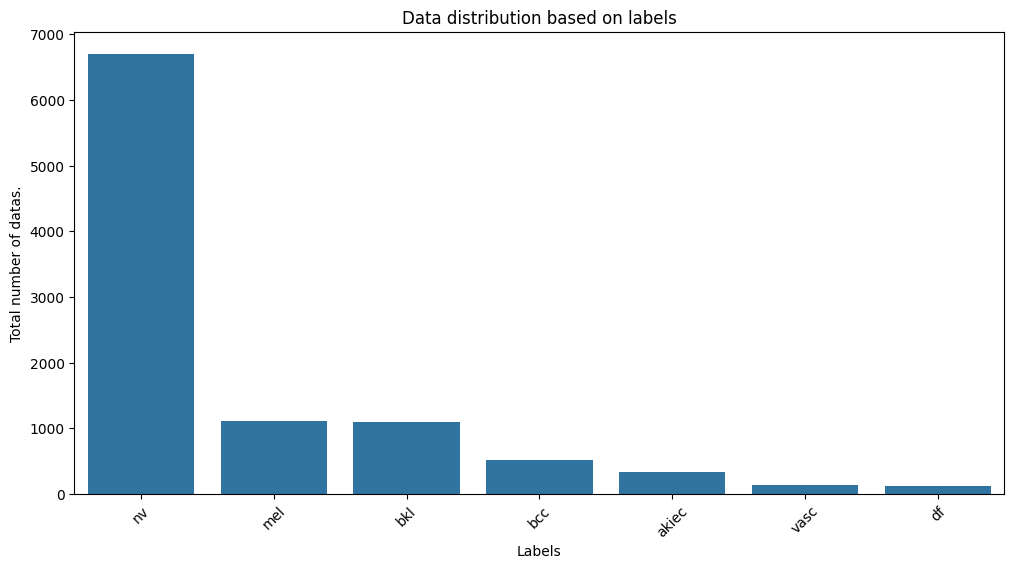

In [10]:
import seaborn as sns
plt.figure(figsize = (12,6))
counts = df['dx'].value_counts()
sns.barplot(counts,label = counts.index)
plt.ylabel('Total number of datas.')
plt.xlabel('Labels')
plt.title('Data distribution based on labels')
plt.xticks(rotation=45)
plt.show()

As we can observe from the above plot that, the class nv has very high amount of data compared to other classes, showing dataimbalance in the dataset.

**Splitting of the dataset into train and test based on groupshufflesplit rather than random split as the same lesion_id cannot be in both training as well as test dataset. Otherwise, this will lead to data leakage**

In [11]:
from sklearn.model_selection import GroupShuffleSplit
gss = GroupShuffleSplit(n_splits=1, random_state=42, test_size=0.1)  #as we need only one train-test split, we are using nsplits of 1 and we are extracting about 10% of the total lesion_id as the test dataset
train_index, test_index = next(gss.split(df,groups = df['lesion_id']))  #splitting the dataset based on the lesion_id column


Splitting the dataset into train and test dataset based on the groupshuffle split

In [12]:
df_train = df.iloc[train_index] #this dataset is only for training the model
print(df_train.head())
print('training data shape:', df_train.shape)

     lesion_id          image_id   dx dx_type   age   sex localization  \
0  HAM_0000118  ISIC_0027419.jpg  bkl   histo  80.0  male        scalp   
1  HAM_0000118  ISIC_0025030.jpg  bkl   histo  80.0  male        scalp   
2  HAM_0002730  ISIC_0026769.jpg  bkl   histo  80.0  male        scalp   
3  HAM_0002730  ISIC_0025661.jpg  bkl   histo  80.0  male        scalp   
4  HAM_0001466  ISIC_0031633.jpg  bkl   histo  75.0  male          ear   

              class  
0  benign_keratoses  
1  benign_keratoses  
2  benign_keratoses  
3  benign_keratoses  
4  benign_keratoses  
training data shape: (8989, 8)


In [13]:
df_test = df.iloc[test_index]  #we gonna use this dataset for testing our model
print(df_test.head())
print('test data shape:', df_test.shape)

      lesion_id          image_id   dx dx_type   age   sex localization  \
6   HAM_0002761  ISIC_0029176.jpg  bkl   histo  60.0  male         face   
7   HAM_0002761  ISIC_0029068.jpg  bkl   histo  60.0  male         face   
18  HAM_0007571  ISIC_0029836.jpg  bkl   histo  70.0  male        chest   
19  HAM_0007571  ISIC_0032129.jpg  bkl   histo  70.0  male        chest   
34  HAM_0005388  ISIC_0027815.jpg  bkl   histo  80.0  male        chest   

               class  
6   benign_keratoses  
7   benign_keratoses  
18  benign_keratoses  
19  benign_keratoses  
34  benign_keratoses  
test data shape: (1026, 8)


In [16]:
def split_lesion_wise(df,test_size,seed):
    gss= GroupShuffleSplit(n_splits=1, random_state=seed, test_size = test_size)   #n_splits = 1 for only one train_test split 
    train_index,valid_index = next(gss.split(df,groups = df['lesion_id']))  #splitting the dataset based on the lesion_id column
    return IndexSplitter(valid_index)(df)
    
    

Designing the datablock for loading the data

In [21]:
path = Path('/kaggle/input/datasets/nour12347653/skin-disease-detection-dataset-ham10000-isic/processed_images_dataset/processed_images')
datablock = DataBlock(
    blocks = (ImageBlock,CategoryBlock),
    splitter = lambda df: split_lesion_wise(df,test_size = 0.1,seed = 42),   #here we are splitting 
    get_x=ColReader('image_id', pref=path),
    get_y=ColReader('dx'),
    item_tfms=Resize(224, method=ResizeMethod.Pad, pad_mode='zeros'),
    batch_tfms=aug_transforms(size=224, max_rotate=20, max_zoom=1.1, max_lighting=0.2)
               + [Normalize.from_stats(*imagenet_stats)]
)

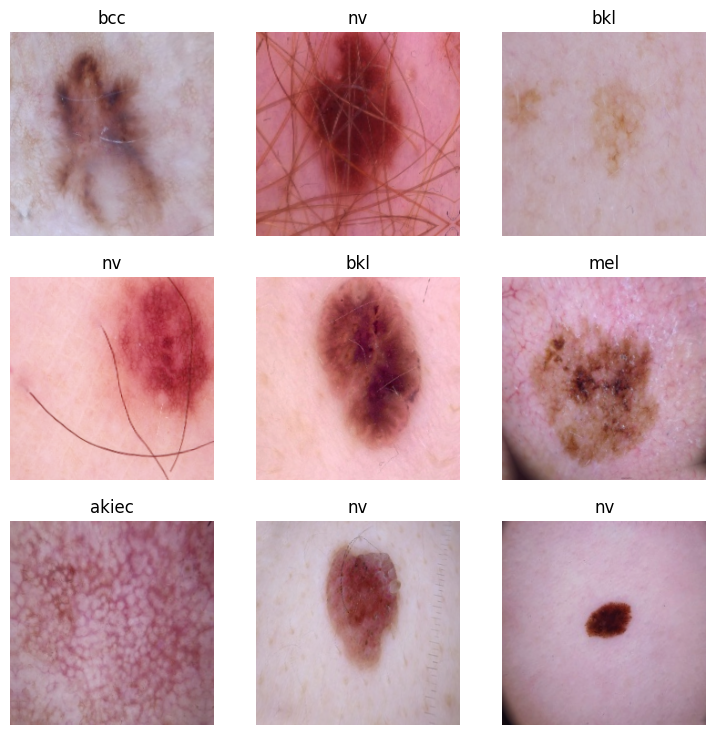

In [22]:
dls = datablock.dataloaders(df_train)
dls.show_batch()

Calculation of the weights of the classes such that our model will penalize more on wrong predictions on rare classes than that on common classes.

In [24]:
from sklearn.utils.class_weight import compute_class_weight
classes = dls.vocab  #list of classes obtained with the help of dataloader
class_weights = compute_class_weight('balanced',classes=np.arange(len(classes)),y = df_train['dx'].map(dls.vocab.o2i))
class_weights = torch.tensor(class_weights, dtype = torch.float32, device = default_device())
